In [150]:
import sounddevice as sd
import soundfile as sf
from scipy import fftpack
import librosa
import matplotlib.pyplot as plt
import numpy as np

1. Sygnał audio

Rozdzielczość bitowa: float32
Częstotliwość próbkowania: 48000
Czas trwania: 5.717333333333333
Liczba kanałów: 1


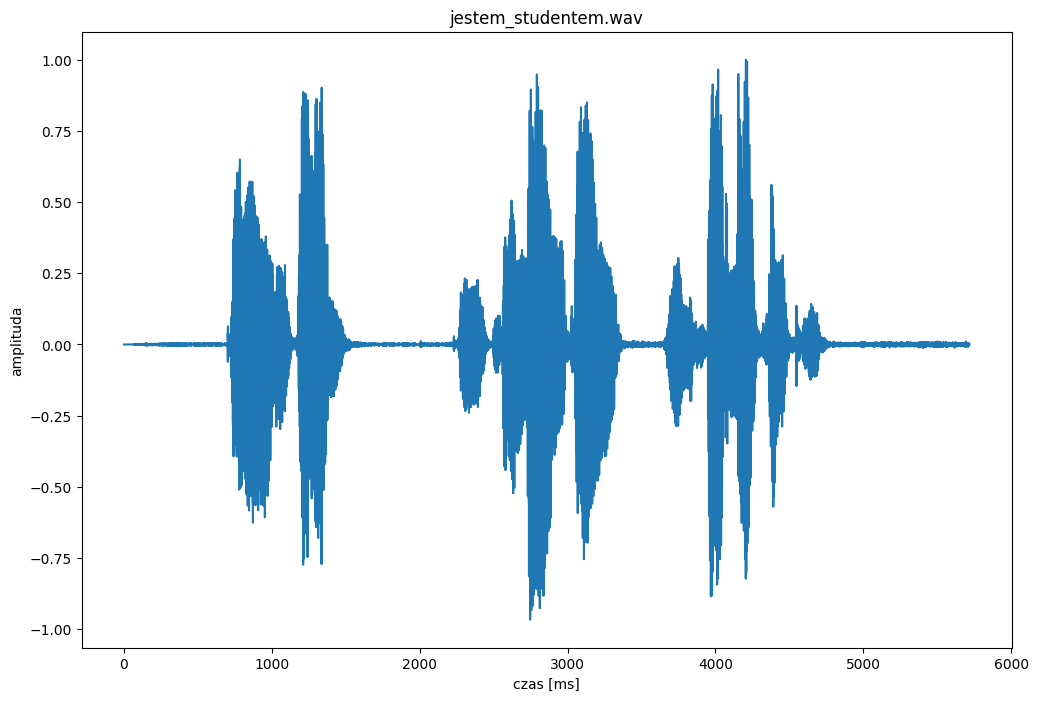

In [151]:
file = 'jestem_studentem.wav'

s, fs = sf.read(file, dtype='float32')
#sd.play(s, fs)
#status = sd.wait()

s = s / np.max(s)
Tc = len(s)/fs
liczba_kanalow = s.ndim
print("Rozdzielczość bitowa:", s.dtype)
print("Częstotliwość próbkowania:", fs)
print("Czas trwania:", Tc)
print("Liczba kanałów:", liczba_kanalow)
N = int(np.ceil(Tc*fs))
t = []

for i in range(N):
    t.append(i/fs*1000)
plt.figure(figsize=(12, 8))
plt.plot(t, s)
plt.title(f"{file}")
plt.xlabel('czas [ms]')
plt.ylabel('amplituda')
plt.show()

2. Wykorzystanie okien kroczących

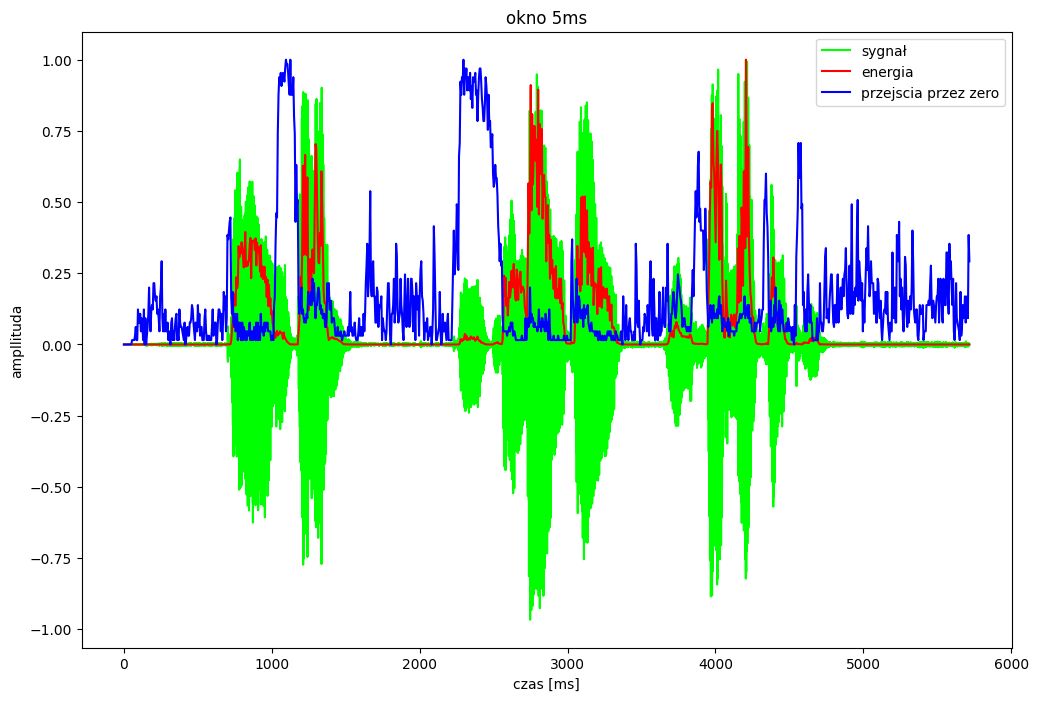

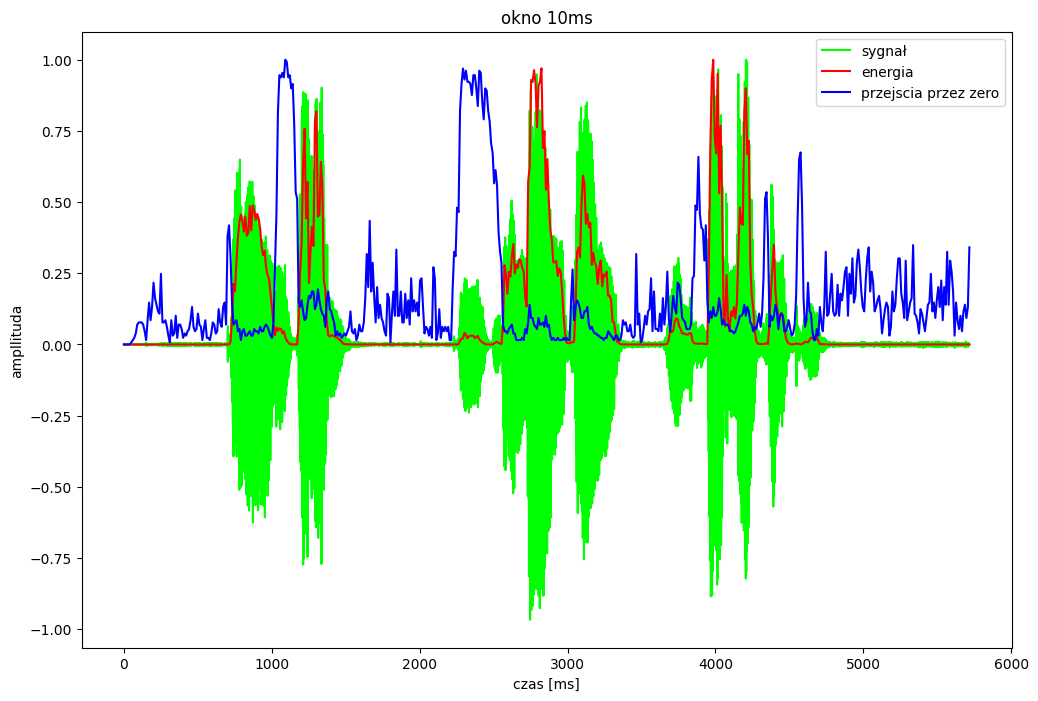

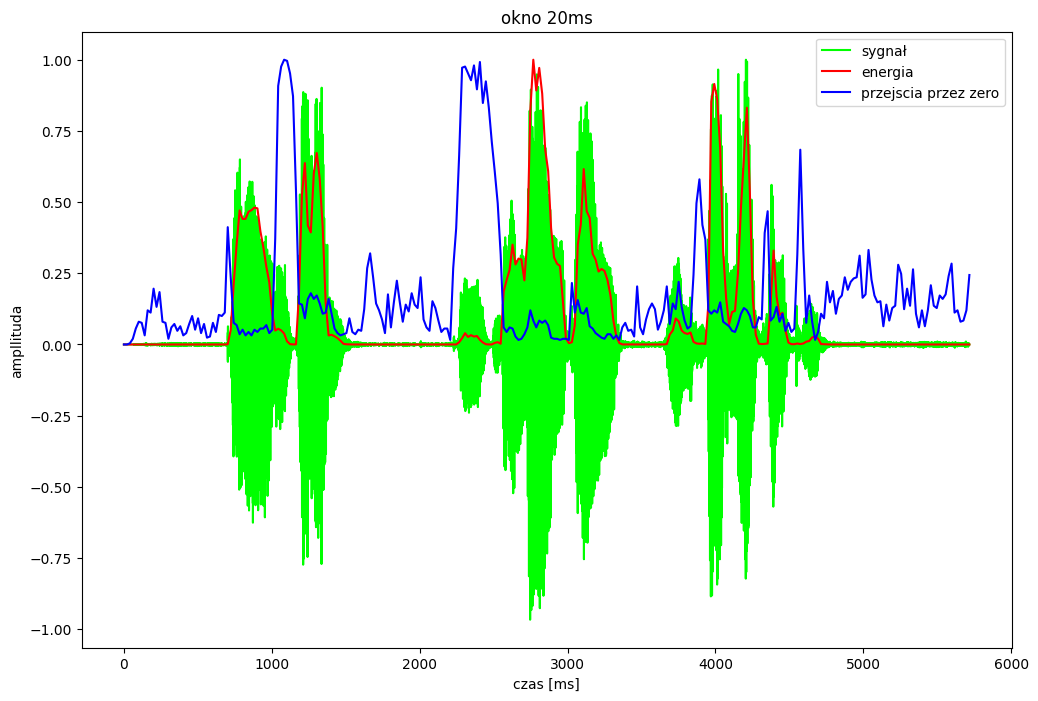

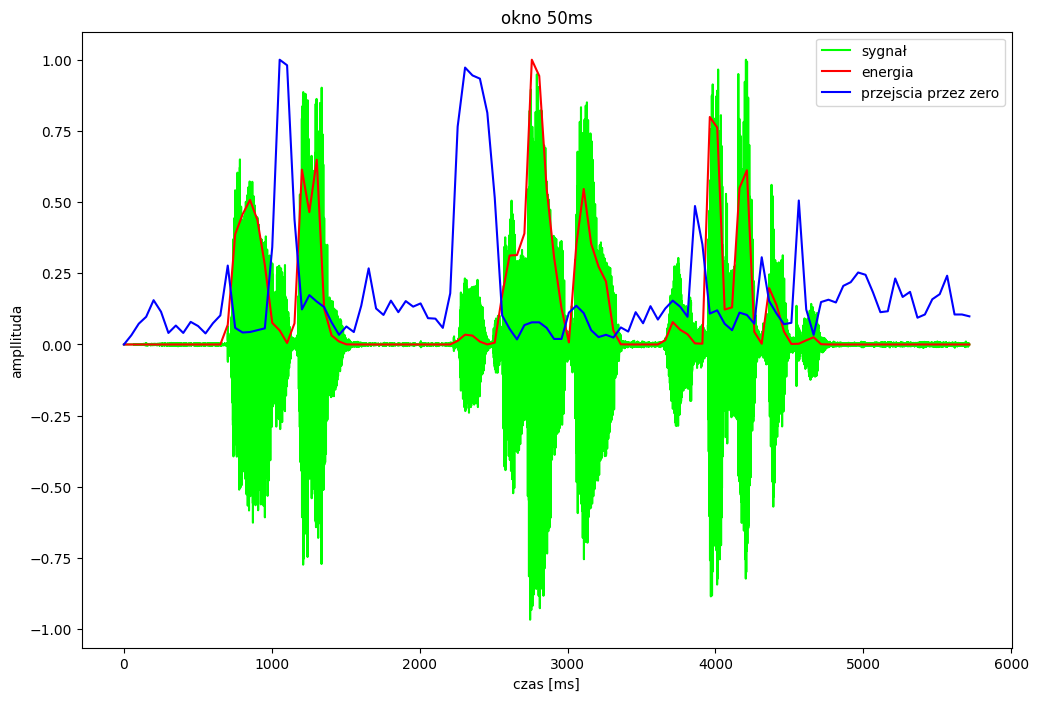

In [152]:
def generuj_ramki(s, dlugosc_ramki=10):
    ramki = []
    dr = int(np.ceil(dlugosc_ramki * fs / 1000)) #długość ramki(liczba próbek)
    for i in range(0, len(s), dr):
        ramki.append([s[i:i + dr]])
    return ramki

def E(ramka): #funkcja energii
    return np.sum(ramka**2)

def Z(ramka): #funkcja przejść przez zero
    sum = 0
    for i in range(len(ramka)-1):
        if (ramka[i]*ramka[i+1]) < 0:
            sum += 1
    return sum

def rysuj_ramki(ramki, dlugosc_ramki=10):
    Ej = []
    Zj = []
    for r in ramki:
        Ej.append(E(r[0]))
        Zj.append(Z(r[0]))
    Ej = Ej / np.max(Ej)
    Zj = Zj / np.max(Zj)
    tframe = np.linspace(0, np.max(t), len(Ej))
    plt.figure(figsize=(12, 8))
    plt.title(f"okno {dlugosc_ramki}ms")
    plt.plot(t, s, 'lime', label='sygnał')
    plt.plot(tframe, Ej, 'r', label='energia')
    plt.plot(tframe, Zj, 'b', label='przejscia przez zero')
    plt.xlabel('czas [ms]')
    plt.ylabel('ampllituda')
    plt.legend()
    plt.show()
    
ramki = generuj_ramki(s, 10)
ramki5 = generuj_ramki(s, 5)
ramki20 = generuj_ramki(s, 20)
ramki50 = generuj_ramki(s, 50)

rysuj_ramki(ramki5, 5)
rysuj_ramki(ramki, 10)
rysuj_ramki(ramki20, 20)
rysuj_ramki(ramki50, 50)

3.

Maksima funkcji energii wskazują kiedy sygnał ma największa amplitudę energii, często odpowiadają dźwięcznym częściom sygnału, natomiast minima mogą wskazywać na ciszę lub bezdźwięczne częsci sygnału.

Maksima funkcji przejść przez zero mogą wskazywać segmenty bezdźwięczne, natomiast minima segmenty dźwięczne.

Wysoka energia i mała liczba przejść przez zero może wskazywać na wystąpienie samogłoski.

Niska energia i duża liczba przejśc przez zero może wskazywac na wystąpienie spółgłoski bezdźwięcznej.

4.

Im krótsza ramka, tym bardziej precyzyjne wykrywanie zmian.

3. Analiza częstotliwości

In [153]:
T=2.93
def funkcja(s, fs, T, okno):
    x=int(T*fs)
    samogloska = s[x:x+2048]
    samogloska_h = samogloska * np.hamming(2048)
    hamming = np.hamming(2048)

    yf = fftpack.fft(samogloska_h)
    widmo = np.log(np.abs(yf))
    freq = np.linspace(0, fs, len(widmo))

    f0 = librosa.yin(samogloska, fmin=50, fmax=500, sr=fs)
    print("Częstotliwość podstawowa (F0):", f0[0], "Hz")

    # plt.subplot()
    # [3,1,1                     ]
    # [3,4,5][3,4,6][3,4,7][3,4,8]
    # [3,1,3                     ]

    plt.figure(figsize=(16, 10))
    t=np.arange(len(s))/fs*1000
    plt.subplot(3, 1, 1)
    plt.plot(t,s)
    plt.plot([x/fs*1000,x/fs*1000], [-1,1], "--k")
    plt.ylabel("Amplituda")

    plt.subplot(3, 4, 5)
    plt.plot(samogloska)
    plt.title("Fragment sygnału")

    plt.subplot(3, 4, 6)
    plt.plot(hamming)
    plt.title("Okno Hamminga")

    plt.subplot(3, 4, 7)
    plt.plot(samogloska_h)
    plt.title("Sygnał * Okno")

    plt.subplot(3, 4, 8)
    plt.plot(np.abs(yf[:1024]))
    plt.title("Widmo amplitudowe")

    plt.subplot(3, 1, 3)
    plt.plot(freq, widmo)
    plt.title("Widmo amplitudowe (log abs fft)")
    plt.xlim(0, 5000)

    plt.tight_layout()
    plt.show()
    
    a = librosa.lpc(okno, order=p)
    a = np.hstack([a, np.zeros(2048 - a.size)])
    yf = fftpack.fft(a)
    widmolpc = np.log(np.abs(yf)) * (-1)
    
    freq = np.linspace(0, fs, len(a))

    plt.figure(figsize=(12, 8))
    plt.plot(freq, widmo, label='widmo')
    plt.plot(freq, widmolpc - 2.5, label='widmoLPC')
    plt.title('Widmo amplitudowe i LPC')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Amplituda')
    plt.legend()
    plt.xlim(0, 10000)
    plt.show()

4. Rozpoznawanie samogłosek ustnych

Częstotliwość podstawowa (F0): 116.38080738573731 Hz


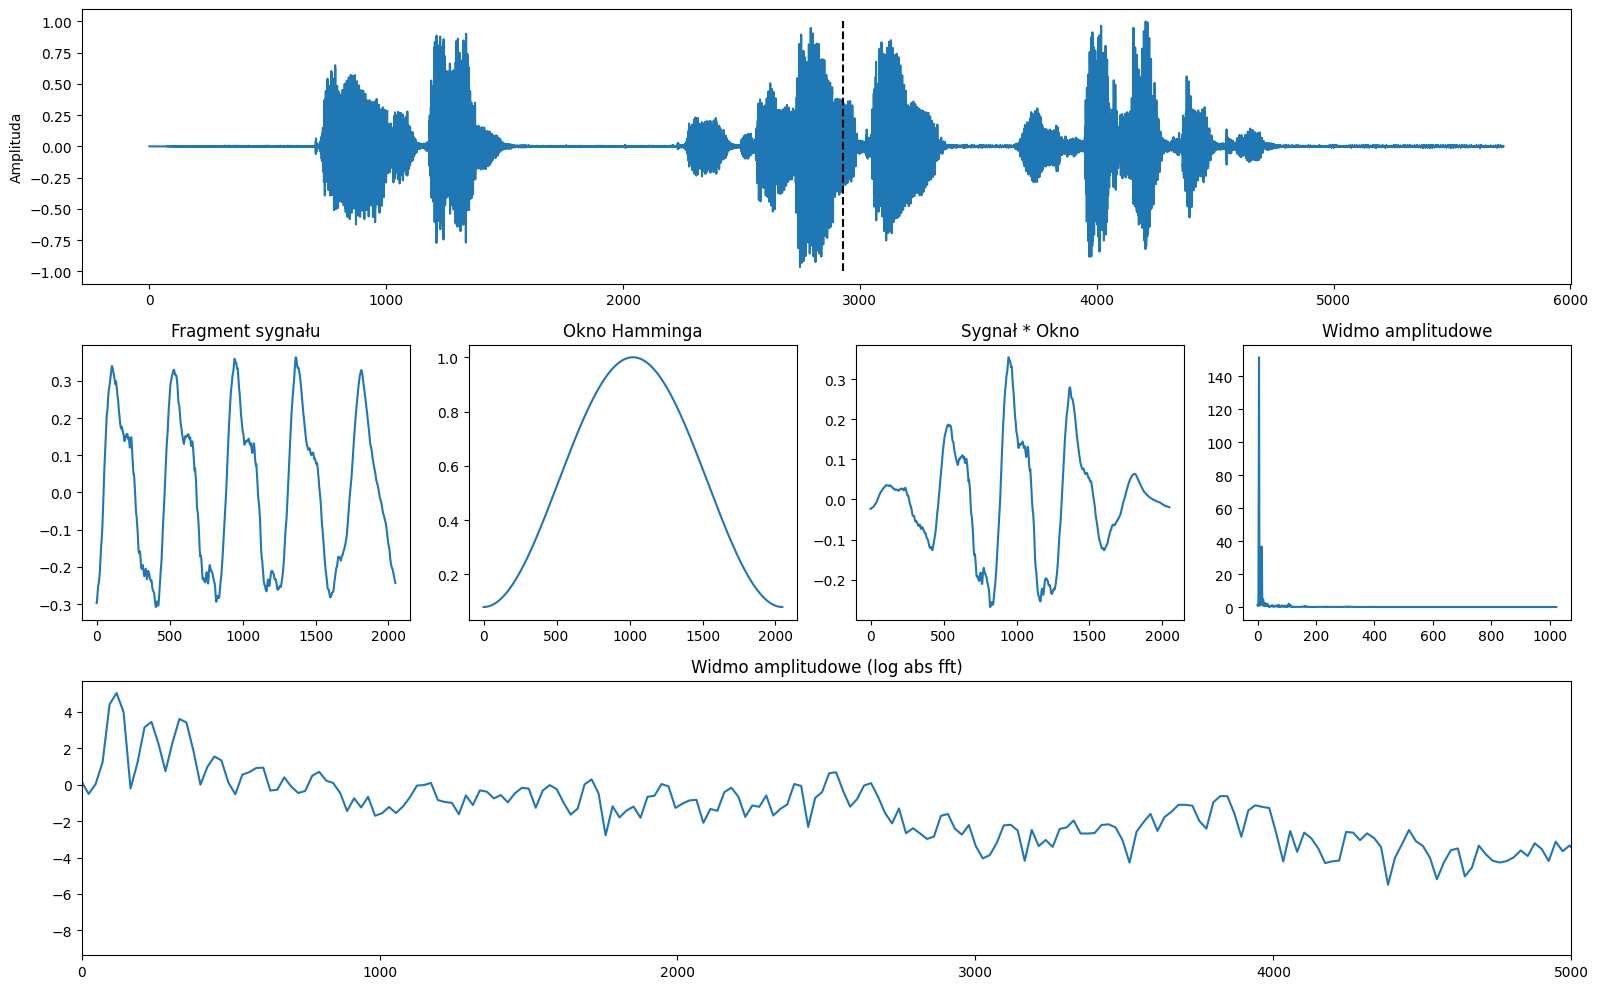

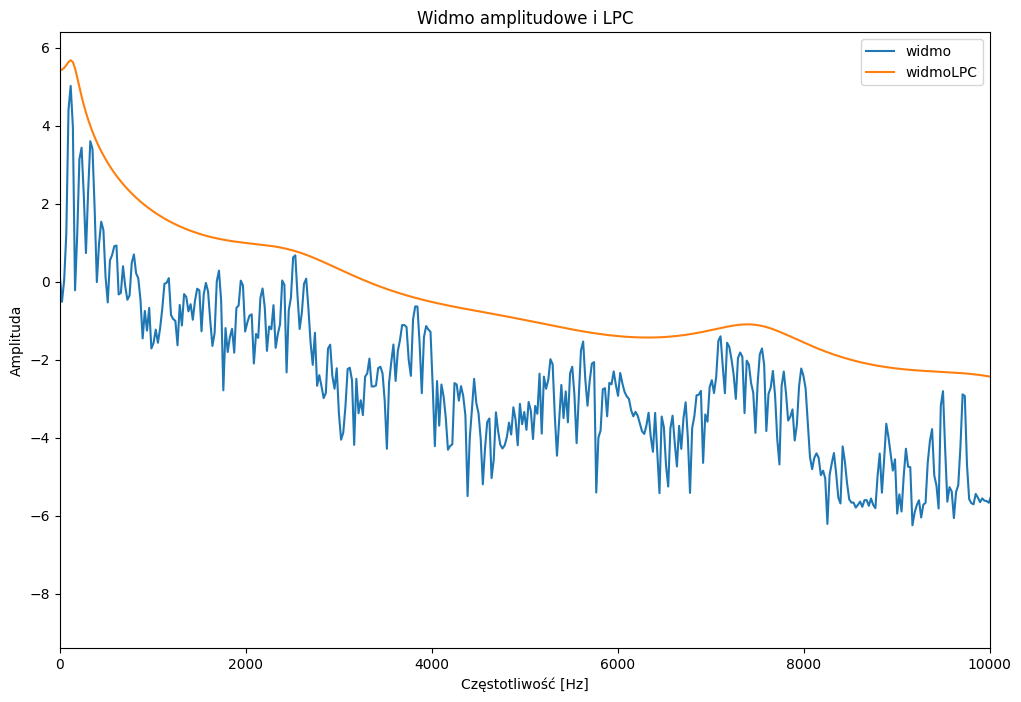

Częstotliwość podstawowa (F0): 124.7802461579328 Hz


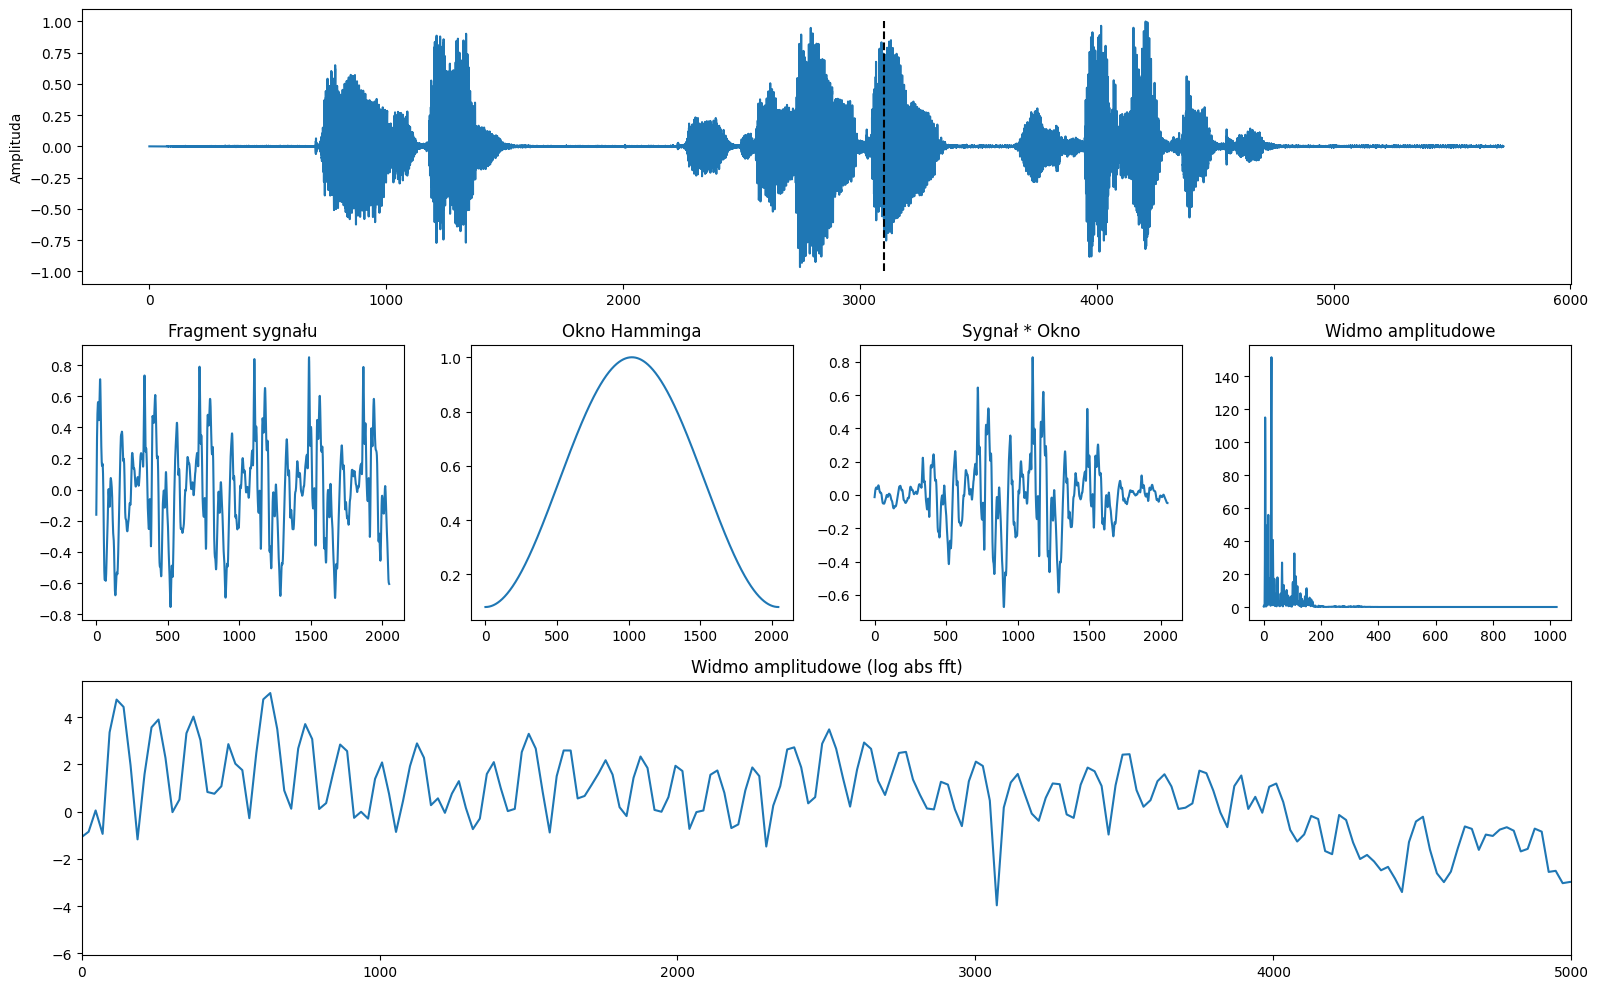

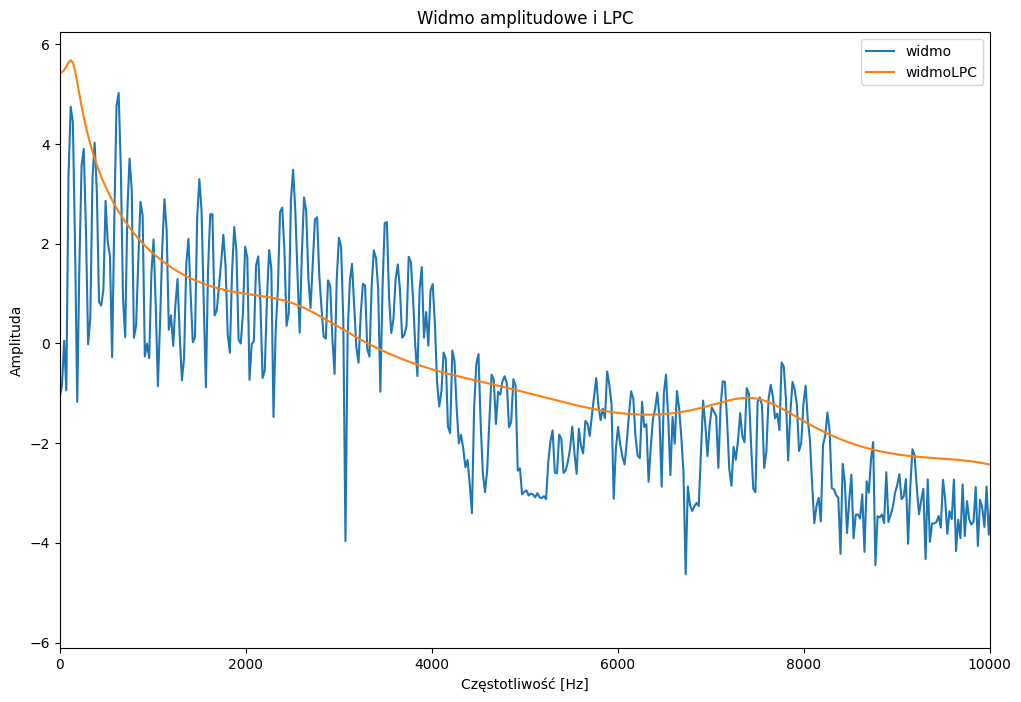

In [154]:
funkcja(s, fs, 2.93, okno)

funkcja(s, fs, 3.1, okno)

3.

LPC - próbka sygnału może być przedstawiona jako liniowa komibnacja poprzednich próbek. Wykorzystywana jest w analizie mowy.